In [1]:
# ABSA Pipeline untuk Kinerja Pondok Pesantren
# Instalasi library yang diperlukan
!pip install pandas numpy scikit-learn tensorflow matplotlib seaborn gensim openpyxl nltk wordcloud


In [ ]:

# =============================================================================
# STEP 3: MANUAL ASPECT DETERMINATION
# =============================================================================

def create_aspect_dictionary():
    """
    Create aspect dictionary with root words for each aspect
    """
    aspect_dict = {
      'Kualitas Guru': [
        # Nilai awal
        'guru', 'pengajar', 'ustaz', 'ustadz', 'ustad', 'pengasuh', 'pembimbing',
        'ajar', 'mengajar', 'bimbingan', 'didik', 'mendidik', 'pendidikan',
        'kompeten', 'berkualitas', 'professional', 'ahli', 'pintar', 'cerdas',

        # Tambahan berdasarkan kalimat.txt
        'ustadzah', 'nangguru', 'pak ustadz', 'ibu ustadzah', 'bunda husniati', 'uni husni',
        'pimpinan pondok', 'pimpinan pesantren', 'pembina', 'pemateri', 'pemimpin',
        'murobbi', 'gurunda', 'asatidz', 'dosen', 'mentor', 'pelatih',
        'penguji', 'pemilik ilmu', 'panutan', 'teladan', 'pendamping',
        'pengasuhan', 'pengabdian', 'pengaruh', 'motivator', 'penasehat',
        'pemberi ilmu', 'penyampai ilmu', 'penceramah', 'penyuluh', 'penggerak',
        'pengembang', 'pembangun karakter', 'pengarah', 'penguat', 'pemantau',
        'pembimbing spiritual', 'pengajar tahfiz', 'pengajar tahsin', 'peneguh akhlak',
        'ustadz pembina', 'guru favorit', 'guru terbaik', 'pengasuh terbaik',
        'ilmu dari ustadz', 'jasa guru', 'amal jariyah', 'pencerah', 'penuntun',
        'pembentuk karakter', 'guru inspiratif', 'pengajar andalan', 'tokoh pendidikan',
        'ustadz pengajar', 'ustadz yang bijak', 'ustadz yang sabar', 'ustadz yang tawadhu',
        'ustadz yang tegas', 'ustadz yang ramah', 'ustadz yang penyayang', 'ustadz yang adil',
        'pengajar berkualitas', 'guru pembina', 'guru motivator', 'guru penuh cinta',
        'ustadz profesional', 'guru santun', 'guru religius', 'guru berkharisma',
        'pendidik sejati', 'guru sabar', 'guru berilmu', 'guru berdedikasi', 'guru teladan',
        'pemimpin berkharisma', 'guru pembentuk karakter', 'guru panutan', 'guru kreatif',
        'guru bijak', 'guru penyabar', 'guru istiqamah', 'guru penuh kasih', 'guru disiplin'
      ],
      'Fasilitas': [
        'fasilitas', 'gedung', 'ruang', 'kelas', 'asrama', 'masjid', 'mushola',
        'perpustakaan', 'laboratorium', 'kantin', 'toilet', 'kamar', 'tempat',
        'sarana', 'prasarana', 'peralatan', 'perlengkapan', 'infrastruktur',
        'panggung', 'lapangan', 'barisan', 'parkiran', 'kursi', 'meja',
        'sound system', 'tempat wudhu', 'tangga', 'teras', 'kamar mandi',
        'area', 'halaman', 'blok', 'atap', 'dinding', 'depan kamera',
        'auditorium', 'panggung gembira', 'spot', 'panggung apresiasi',
        'kelas A', 'kelas B', 'kelas C', 'peralatan olahraga', 'barak',
        'seragam pondok', 'peralatan lomba', 'sarana olahraga', 'arena',
        'lokasi kegiatan', 'tempat latihan', 'ruang ujian', 'tenda',
        'ruang tahfidz', 'ruang belajar', 'ruang makan', 'dapur santri',
        'tempat ibadah', 'lokasi parkir', 'kamar santri', 'tempat tidur',
        'lemari', 'jemuran', 'penataan tempat', 'area upacara', 'papan tulis',
        'infokus', 'proyektor', 'papan nama kelas', 'karpet', 'rak sepatu',
        'loker', 'akses jalan', 'akses air', 'tempat istirahat', 'tempat duduk',
        'lokasi foto', 'view udara', 'arsitektur pondok', 'bangunan pondok',
        'layout pondok', 'ruang OSPI', 'panggung OSPI', 'pos keamanan',
        'ruang administrasi', 'pos penjagaan', 'alat kebersihan', 'alat tulis',
        'alat mandi', 'peralatan ibadah', 'peralatan masak', 'kebutuhan santri',
        'ruang wali santri', 'gedung pertemuan', 'gedung kelas baru',
        'area santri putri', 'area santri putra', 'arena pencak silat',
        'studio rekaman', 'studio podcast', 'kios kantin', 'kasur', 'bantal'
      ],
      'Lingkungan': [
        'lingkungan', 'sekitar', 'daerah', 'lokasi', 'tempat', 'suasana',
        'atmosfer', 'kondisi', 'situasi', 'tenang', 'nyaman', 'sejuk',
        'bersih', 'kotor', 'sehat', 'aman', 'strategis',
        'asri', 'damai', 'hijau', 'rapi', 'tertib', 'khidmat', 'semarak',
        'penuh semangat', 'cerah', 'cuaca cerah', 'lingkungan pondok',
        'lingkungan pesantren', 'suasana pondok', 'suasana kelas',
        'suasana asrama', 'suasana upacara', 'view udara', 'pemandangan',
        'udara segar', 'udara sejuk', 'tempat tenang', 'suasana religius',
        'suasana Islami', 'suasana kekeluargaan', 'suasana meriah',
        'suasana bersahabat', 'suasana gembira', 'suasana ceria',
        'suasana belajar', 'suasana spiritual', 'suasana pagi', 'suasana sore',
        'suasana ramadhan', 'suasana pesantren', 'suasana libur', 'suasana hujan',
        'kawasan pondok', 'area pondok', 'kompleks pesantren', 'lingkungan bersih',
        'lingkungan sehat', 'lingkungan nyaman', 'lingkungan Islami',
        'suasana aman', 'rindang', 'berkawah', 'panas', 'dingin',
        'tenang dan damai', 'ramah', 'guyub', 'akrab', 'penuh kekeluargaan',
        'rasa tenteram', 'kehidupan pondok', 'hari-hari di pondok', 'kesan pondok',
        'penghuni pondok', 'suasana lomba', 'suasana tahfiz', 'keramaian',
        'kerapihan', 'suasana kegiatan', 'suasana belajar mengajar'
      ],
    'Kegiatan Pondok': [
        'kegiatan', 'program', 'acara', 'event', 'agenda', 'jadwal',
        'ekstrakurikuler', 'ekskul', 'organisasi', 'osis', 'rohis',
        'pengajian', 'kajian', 'ceramah', 'kultum', 'sholat', 'tahfidz', 'ospi',
        'tahsin', 'tasmi', 'tahfizhul', 'hafalan', 'daurah', 'apel', 'upacara',
        'muhadarah', 'ujian', 'tulis', 'lisan', 'tahriri', 'haflah',
        'panggung gembira', 'one night with alumni', 'hari santri', 'maulid',
        'peringatan isra', 'peringatan maulid', 'mabit', 'outing class',
        'ziarah', 'mukhayyam', 'munaqosah', 'musabaqah', 'khataman',
        'madrasah fest', 'mahakarya', 'opening ceremony', 'closing ceremony',
        'seminar', 'workshop', 'pentas seni', 'pentas budaya', 'lomba antar kamar',
        'pelatihan', 'diskusi', 'presentasi', 'praktikum', 'kegiatan qurban',
        'sholat berjamaah', 'amalan pondok', 'sholat dhuha', 'sholat malam',
        'tadarus', 'dzikir bersama', 'doa bersama', 'muhasabah', 'rapat',
        'sidang kelas', 'kegiatan malam', 'kegiatan subuh', 'kegiatan pagi',
        'kegiatan sore', 'pengarahan', 'arahan', 'briefing', 'pelantikan',
        'pengukuhan', 'OSPI', 'pembukaan', 'penutupan', 'pawai', 'karnaval',
        'kontes', 'kompetisi', 'simulasi', 'try out', 'haflah akhirussanah',
        'malam bina iman dan taqwa', 'praktik ibadah', 'kegiatan istighosah',
        'kegiatan salat jumat', 'pembacaan yasin', 'praktik khutbah',
        'kegiatan sosial', 'kegiatan bakti', 'hari besar Islam',
        'kegiatan bersama wali santri', 'kunjungan wali santri',
        'rekaman', 'syuting', 'gladi', 'kegiatan lomba', 'kegiatan motivasi',
        'motivasi pagi', 'sharing session', 'kunjungan alumni', 'ujian praktik',
        'penampilan santri', 'latihan pencak silat', 'peragaan'
      ],

   'Pembinaan Karakter': [
    # Nilai awal
    'karakter', 'akhlak', 'moral', 'etika', 'sopan', 'santun', 'adab',
    'disiplin', 'tertib', 'patuh', 'taat', 'hormat', 'menghormati',
    'pembinaan', 'pembentukan', 'mendidik', 'membangun', 'mengembangkan',

    # Tambahan dari kalimat.txt dan konteks pondok
    'pembiasaan', 'kesopanan', 'kerapian', 'kerendahan hati', 'tawadhu',
    'kesabaran', 'keteguhan', 'tanggung jawab', 'keteladanan', 'kemandirian',
    'ketaatan', 'keikhlasan', 'kepatuhan', 'kejujuran', 'komitmen',
    'penguatan karakter', 'perilaku', 'ahlakul karimah', 'teladan',
    'sikap', 'pengendalian diri', 'kesungguhan', 'niat baik', 'taat aturan',
    'kedisiplinan', 'pengarahan', 'penguatan nilai', 'kebiasaan baik',
    'pengawasan', 'pembimbingan', 'pengasuhan karakter', 'pembentukan akhlak',
    'pendidikan karakter', 'sikap hormat', 'kebijaksanaan', 'kekonsistenan',
    'motivasi diri', 'pantang menyerah', 'kerja keras', 'beradab', 'beretika',
    'tanggung jawab pribadi', 'penghormatan', 'ketaatan santri', 'kesalehan',
    'nasihat akhlak', 'pembentukan kepribadian', 'jiwa kepemimpinan',
    'nilai-nilai islami', 'akhlak mulia', 'taat guru', 'berahlak',
    'pengingat adab', 'jiwa disiplin', 'sikap spiritual', 'nilai kepribadian',
    'sikap positif', 'jiwa mandiri', 'mental tangguh', 'respek', 'sikap sopan'
],
    'Prestasi': [
    # Nilai awal
    'prestasi', 'juara', 'menang', 'pemenang', 'lomba', 'kompetisi',
    'kejuaraan', 'olimpiade', 'festival', 'penghargaan', 'award',
    'berprestasi', 'unggul', 'terbaik', 'hebat', 'luar biasa','raih', 'raihan',

    # Tambahan dari kalimat.txt dan konteks pondok
    'peringkat', 'ranking', 'piala', 'medali', 'trophy', 'sertifikat',
    'duta', 'delegasi', 'finalis', 'grand final', 'tampil terbaik',
    'sukses tampil', 'kemenangan', 'gelar', 'title', 'penampilan terbaik',
    'hasil gemilang', 'hasil membanggakan', 'santri berprestasi',
    'prestasi nasional', 'prestasi internasional', 'tampil luar biasa',
    'penghargaan khusus', 'prestasi akademik', 'prestasi non-akademik',
    'santri inspiratif', 'hafiz terbaik', 'tahfidz terbaik',
    'qori terbaik', 'tilawah terbaik', 'madrasah fest', 'juara umum',
    'juara 1', 'juara 2', 'juara 3', 'peraih medali emas',
    'peraih medali perak', 'peraih medali perunggu',
    'juara favorit', 'unggulan', 'terpilih', 'hasil maksimal',
    'prestasi membanggakan', 'santri andalan', 'santri juara',
    'juara lomba tilawah', 'juara pidato', 'juara bahasa arab',
    'performa terbaik', 'membawa pulang piala', 'mengharumkan nama pondok',
    'prestasi membanggakan pesantren', 'pencapaian luar biasa',
    'pencapaian gemilang', 'santri hebat', 'tim berprestasi',
    'peringkat nasional', 'peringkat provinsi', 'peringkat kabupaten',
    'kompetitor unggul', 'gelar juara', 'berhasil meraih juara'
],
    'Akademik': [
    # Nilai awal
    'akademik', 'pelajaran', 'mata pelajaran', 'mapel', 'kurikulum',
    'belajar', 'pembelajaran', 'pendidikan', 'sekolah', 'kelas',
    'ujian', 'ulangan', 'tes', 'nilai', 'rapor', 'lulusan', 'alumni',

    # Tambahan dari kalimat.txt dan konteks pesantren
    'belajar kelompok', 'pembahasan soal', 'pemahaman materi',
    'penguasaan materi', 'tugas', 'PR', 'remedial', 'bimbingan belajar',
    'buku pelajaran', 'kitab', 'pelajaran kitab', 'bahasa arab',
    'bahasa inggris', 'nahwu', 'shorof', 'fiqih', 'tauhid', 'hadis', 'tajwid',
    'tahsin', 'tahfizhul', 'muhadarah', 'syarah', 'lughah', 'ilmu alat',
    'kelas A', 'kelas B', 'kelas C', 'pembelajaran aktif', 'kelas interaktif',
    'kelas unggulan', 'kelas khusus', 'kelas regular', 'evaluasi', 'koreksi',
    'pembagian rapor', 'peringkat kelas', 'soal', 'penguji', 'pengajar',
    'ruang ujian', 'jadwal ujian', 'pengawas ujian', 'hasil ujian',
    'ujian tulis', 'ujian lisan', 'tahriri', 'tahriri lisan', 'penilaian',
    'ujian akhir semester', 'ujian tengah semester', 'PAS', 'PAT',
    'rapat guru', 'rapat akademik', 'rapat nilai', 'ujian praktik',
    'try out', 'ujian kelulusan', 'pengumuman kelulusan', 'angkatan',
    'angkatan alumni', 'program akademik', 'hari belajar', 'hari ujian',
    'bel masuk', 'jam pelajaran', 'absensi', 'daftar hadir', 'pengembangan akademik',
    'pengayaan materi', 'prestasi akademik', 'kelas online', 'kelas tatap muka',
    'kelas hybrid', 'ujian masuk', 'tes masuk', 'jadwal pelajaran',
    'proses belajar mengajar', 'target hafalan', 'rencana belajar',
    'catatan guru', 'catatan pelajaran', 'santri belajar', 'santri akademik',
    'santri unggulan', 'kelas tahfidz', 'kelas umum', 'kelas internasional'
],
   'Motivasi/Spiritual': [
    # Nilai awal
    'motivasi', 'semangat', 'inspirasi', 'dorongan', 'dukungan',
    'spiritual', 'rohani', 'iman', 'taqwa', 'ibadah', 'doa',
    'dzikir', 'muhasabah', 'taubat', 'istighfar', 'syukur',

    # Tambahan dari kalimat.txt dan konteks pesantren
    'berkah', 'aamiin', 'nasihat', 'murobbi', 'muhasabah diri',
    'pengingat', 'tausiyah', 'mauizah', 'tawakal', 'sabar', 'ikhlas',
    'penguatan iman', 'kekuatan batin', 'hati tenang', 'hati lapang',
    'hati yang bersih', 'penghibur jiwa', 'doa restu', 'doa orang tua',
    'doa ustadz', 'nasihat ustadz', 'nasihat guru', 'hikmah',
    'mendekatkan diri', 'nilai ruhani', 'ruhiyah', 'siraman rohani',
    'ceramah agama', 'motivator', 'doa bersama', 'renungan', 'kekuatan doa',
    'semangat santri', 'mental kuat', 'istiqamah', 'niat lillahi taala',
    'ikhtiar', 'tawadhu', 'pengorbanan', 'sujud', 'shalat malam',
    'shalat dhuha', 'istighotsah', 'asmaul husna', 'sholawat',
    'berjuang di jalan Allah', 'sabar dalam ujian', 'kekuatan spiritual',
    'mimpi besar', 'harapan tinggi', 'mimpi menjadi ulama',
    'taqarrub', 'syahdu', 'berzikir', 'ruang spiritual', 'jiwa semangat',
    'jiwa penuh syukur', 'jiwa religius', 'jiwa optimis', 'jiwa istiqamah',
    'nasihat ruhani', 'jiwa santri', 'jiwa pondok', 'jiwa tangguh',
    'penyemangat', 'penggugah hati', 'pembentuk jiwa', 'ruh perjuangan',
    'cita-cita tinggi', 'kekuatan doa', 'jiwa dakwah', 'hidayah', 'rahmat',
    'karunia Allah', 'doa harian', 'doa ujian', 'doa perjalanan', 'pengharapan'
],
   'Sosial': [
        # Nilai awal
        'sosial', 'masyarakat', 'komunitas', 'teman', 'persahabatan',
        'kebersamaan', 'kekeluargaan', 'gotong royong', 'tolong', 'menolong',
        'solidaritas', 'peduli', 'empati', 'simpati', 'dermawan',
        'bantu', 'membantu', 'bantuan', 'relawan', 'donasi', 'musibah',
        'infak', 'sedekah', 'amal', 'korban', 'kebakaran', 'kemanusiaan',
        'aksi', 'kepedulian', 'charity', 'filantropi', 'penyaluran', 'kemasyarakatan',

        # Tambahan kontekstual dari kalimat.txt
        'kunjungan', 'silaturahmi', 'rukun', 'keluarga', 'alumni', 'kerja sama',
        'ziarah', 'berbagi', 'saling', 'temannya', 'rindu', 'salaman', 'ucapan terima kasih',
        'kelompok', 'barisan', 'komando', 'kebanggaan', 'pemberian hadiah', 'kontribusi',
        'dukungan', 'penghargaan', 'pengurus', 'pengabdian', 'pengasuhan', 'sapa', 'temani',
        'ramai', 'kerabat', 'keterlibatan', 'semangat bersama', 'partisipasi', 'ikatan',
        'kekerabatan', 'berkumpul', 'bertemu', 'hadir', 'kompak', 'guyub', 'ramah tamah',
        'perhatian', 'emosional', 'sapa menyapa', 'video call', 'cerita bersama',
        'pertemuan', 'kebersamaan', 'sahabat', 'teman dekat', 'komunitas santri', 'lingkungan sosial',
        'dampingan', 'penguat', 'motivator', 'penghibur', 'bantu teman', 'pegang tangan',
        'kelompok belajar', 'tim kerja', 'kerja kelompok', 'bareng-bareng', 'berkoordinasi',
        'kumpul keluarga', 'lepas rindu', 'pelukan', 'sapaan', 'keramaian', 'bercanda', 'berteman',
        'menemani', 'memeluk', 'berdiskusi', 'berinteraksi', 'berkegiatan', 'berjuang bersama',
        'semangat tim', 'bareng ustadz', 'bareng ustadzah', 'dari keluarga', 'teman seperjuangan',
        'dari rumah', 'pesan dari rumah', 'sapaan dari rumah', 'orang rumah', 'support system',
        'menyemangati', 'bertemu santri', 'santri baru', 'teman satu asrama', 'sahabat dekat',
        'satu kamar', 'teman seangkatan', 'pengunjung', 'pesan moral', 'dukungan sosial',
        'peran serta', 'sumbangan', 'doa bersama', 'penguatan sosial', 'semangat bersama'
    ],
      'Umum': [
          'bagus', 'baik', 'jelek', 'buruk', 'recommended', 'rekomen',
          'puas', 'senang', 'suka', 'kecewa', 'sedih', 'marah',
          'overall', 'keseluruhan', 'secara umum', 'umumnya'
      ]
    }
# 2. Stem semua keyword dalam kamus
def stem_aspect_dictionary(aspect_dict, stemmer):
    stemmed_dict = {}
    for aspect, keywords in aspect_dict.items():
        stemmed_dict[aspect] = [stemmer.stem(k.lower()) for k in keywords]
    return stemmed_dict

# 3. Preprocessing teks
def text_preprocessing(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# 4. Fungsi untuk menentukan aspek
def determine_aspect(text, aspect_dict, stemmer):
    text = text_preprocessing(text)
    stemmed_words = stemmer.stem(text).split()

    aspect_scores = {}
    for aspect, keywords in aspect_dict.items():
        # hitung jumlah keyword yang cocok secara eksak
        matches = sum(1 for word in stemmed_words if word in keywords)
        aspect_scores[aspect] = matches

    # Kembalikan aspek dengan skor tertinggi, atau 'Umum' jika semua 0
    return max(aspect_scores, key=aspect_scores.get) if max(aspect_scores.values()) > 0 else 'Umum'

# 5. Inisialisasi
factory = StemmerFactory()
stemmer = factory.create_stemmer()
aspect_dict = stem_aspect_dictionary(create_aspect_dictionary(), stemmer)

# 6. Terapkan ke DataFrame
df['aspek'] = df['kalimat'].apply(lambda x: determine_aspect(x, aspect_dict, stemmer))

print("Aspect distribution:")
print(df['aspek'].value_counts())

In [2]:
# === IMPORT LIBRARY UTAMA ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# === SKLEARN ===
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

# === TENSORFLOW / KERAS ===
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# === NLP: Gensim & NLTK ===
import gensim
from gensim import corpora

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# === CEK & DOWNLOAD DATASET NLTK YANG WAJIB ===
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

# === VISUALIZATION ===
import matplotlib
from wordcloud import WordCloud

# === STYLE PLOT ===
plt.style.use('default')
sns.set_palette("husl")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
# ===== 1. LOADING DATA =====
print("1. LOADING DATA...")

# Load dataset utama
try:
    df = pd.read_excel('/content/ABSA_db_kalimat_komentar.xlsx')  # Ganti dengan path file Anda
    print(f"Dataset berhasil dimuat: {df.shape}")
    print(f"Kolom: {df.columns.tolist()}")
    print("\nSample data:")
    print(df.head())
except:
    print("File dataset.xlsx tidak ditemukan. Membuat sample data...")
    # Sample data untuk testing
    sample_data = {
        'kalimat': [
            'Guru di pondok ini sangat baik dan sabar dalam mengajar',
            'Fasilitas kamar mandi kotor dan tidak terawat',
            'Lingkungan pondok sangat nyaman untuk belajar',
            'Kegiatan ekstrakurikuler sangat beragam dan menarik',
            'Pembinaan akhlak siswa kurang maksimal',
            'Prestasi akademik pondok ini sangat membanggakan',
            'Kualitas pengajaran Al-Quran sangat baik',
            'Motivasi spiritual dari ustadz sangat menginspirasi',
            'Interaksi sosial antar santri harmonis',
            'Secara umum pondok ini recommended'
        ],
        'ponpes': [
            'Pondok A', 'Pondok A', 'Pondok B', 'Pondok B', 'Pondok A',
            'Pondok C', 'Pondok C', 'Pondok B', 'Pondok A', 'Pondok C'
        ]
    }
    df = pd.DataFrame(sample_data)

# Load lexicon files
try:
    positive_words = pd.read_csv('/content/positive.csv')['word'].tolist()
    negative_words = pd.read_csv('/content/negative.csv')['word'].tolist()
    print(f"\nLexicon berhasil dimuat:")
    print(f"- Kata positif: {len(positive_words)}")
    print(f"- Kata negatif: {len(negative_words)}")
except:
    print("\nFile lexicon tidak ditemukan. Menggunakan lexicon default...")
    # Default lexicon Indonesia
    positive_words = [
        'baik', 'bagus', 'hebat', 'mantap', 'keren', 'luar biasa', 'sempurna',
        'memuaskan', 'terbaik', 'excellent', 'recommended', 'nyaman', 'bersih',
        'rapi', 'lengkap', 'modern', 'canggih', 'profesional', 'ramah',
        'sabar', 'telaten', 'pintar', 'cerdas', 'berpengalaman', 'kompeten',
        'inspiratif', 'motivatif', 'membanggakan', 'prestasi', 'juara',
        'harmonis', 'rukun', 'solid', 'kompak', 'menarik', 'seru', 'asyik'
    ]

    negative_words = [
        'buruk', 'jelek', 'tidak baik', 'mengecewakan', 'payah', 'kurang',
        'kotor', 'bau', 'rusak', 'broken', 'error', 'lambat', 'lelet',
        'mahal', 'tidak worth it', 'sia-sia', 'bosan', 'monoton',
        'tidak profesional', 'kasar', 'galak', 'jutek', 'tidak ramah',
        'tidak sabar', 'tidak kompeten', 'tidak berpengalaman',
        'tidak memotivasi', 'tidak inspiratif', 'memalukan', 'mengecewakan',
        'tidak harmonis', 'ribut', 'berantakan', 'tidak terorganisir'
    ]

print(f"\nTotal data: {len(df)} kalimat")
print(f"Jumlah pondok pesantren: {df['ponpes'].nunique()}")


1. LOADING DATA...
Dataset berhasil dimuat: (8535, 4)
Kolom: ['no', 'nama', 'kalimat', 'ponpes']

Sample data:
   no    nama                                            kalimat  \
0   1  Ainame  Masya Allah, santri PPM Al-Ikhlash turut menye...   
1   2  Ainame  Pemimpin Pondok Al-Ikhlash dengan keren meneri...   
2   3  Ainame  Sehat selalu Pak Ustaz, aamiin. Pemimpin Al-Ik...   
3   4  Ainame  Semangat, anak sholeh Ummi. Semoga dimudahkan ...   
4   5  Ainame  Masya Allah, Alhamdulillah. Ananda Muhammad Dz...   

                   ponpes  
0  PPM AL-Ikhlash Lampoko  
1  PPM AL-Ikhlash Lampoko  
2  PPM AL-Ikhlash Lampoko  
3  PPM AL-Ikhlash Lampoko  
4  PPM AL-Ikhlash Lampoko  

Lexicon berhasil dimuat:
- Kata positif: 3609
- Kata negatif: 6609

Total data: 8535 kalimat
Jumlah pondok pesantren: 3


In [4]:
# ===== 2. PREPROCESSING TEXT =====
print("\n2. PREPROCESSING TEXT...")

# Stopwords Indonesia
stop_words = set(stopwords.words('indonesian'))
additional_stopwords = {'yang', 'dan', 'di', 'ke', 'dari', 'untuk', 'dengan', 'pada', 'adalah', 'ini', 'itu'}
stop_words.update(additional_stopwords)

def preprocess_text(text):
    """Preprocessing text: lowercase, remove punctuation, tokenize, remove stopwords"""
    if pd.isna(text):
        return []

    # Lowercase
    text = text.lower()

    # Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize using simple split
    tokens = text.split()

    # Remove stopwords
    tokens = [token for token in tokens if token not in stop_words and len(token) > 2]

    return tokens

# Apply preprocessing
df['tokens'] = df['kalimat'].apply(preprocess_text)
df['clean_text'] = df['tokens'].apply(lambda x: ' '.join(x) if x else '')

print("Preprocessing selesai!")
print("\nContoh hasil preprocessing:")
for i in range(3):
    print(f"Original: {df['kalimat'].iloc[i]}")
    print(f"Clean: {df['clean_text'].iloc[i]}")
    print(f"Tokens: {df['tokens'].iloc[i]}\n")


2. PREPROCESSING TEXT...
Preprocessing selesai!

Contoh hasil preprocessing:
Original: Masya Allah, santri PPM Al-Ikhlash turut menyerahkan bantuan kepada korban kebakaran di Desa Bonne-Bonne.
Clean: masya allah santri ppm alikhlash menyerahkan bantuan korban kebakaran desa bonnebonne
Tokens: ['masya', 'allah', 'santri', 'ppm', 'alikhlash', 'menyerahkan', 'bantuan', 'korban', 'kebakaran', 'desa', 'bonnebonne']

Original: Pemimpin Pondok Al-Ikhlash dengan keren menerima kunjungan pengurus KKS Rukun Keluarga Sulawesi di Kairo.
Clean: pemimpin pondok alikhlash keren menerima kunjungan pengurus kks rukun keluarga sulawesi kairo
Tokens: ['pemimpin', 'pondok', 'alikhlash', 'keren', 'menerima', 'kunjungan', 'pengurus', 'kks', 'rukun', 'keluarga', 'sulawesi', 'kairo']

Original: Sehat selalu Pak Ustaz, aamiin. Pemimpin Al-Ikhlash menerima kunjungan pengurus KKS Rukun Keluarga Sulawesi di Kairo.
Clean: sehat ustaz aamiin pemimpin alikhlash menerima kunjungan pengurus kks rukun keluarga sulawes

In [5]:
# ===== 3. ASPECT EXTRACTION MENGGUNAKAN LDA =====
print("3. ASPECT EXTRACTION MENGGUNAKAN LDA...")

# Prepare documents for LDA
documents = [tokens for tokens in df['tokens'] if tokens]

# Create dictionary and corpus
dictionary = corpora.Dictionary(documents)
dictionary.filter_extremes(no_below=1, no_above=0.8)
corpus = [dictionary.doc2bow(doc) for doc in documents]

# Train LDA model
num_topics = 10  # Sesuai dengan 10 aspek yang diinginkan
lda_model = gensim.models.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=42,
    passes=10,
    alpha='auto',
    per_word_topics=True
)

print(f"LDA model berhasil dilatih dengan {num_topics} topik")

# Tampilkan topik yang ditemukan
print("\nTopik yang ditemukan oleh LDA:")
for idx, topic in lda_model.print_topics(-1):
    print(f"Topik {idx}: {topic}")

# Get dominant topic for each document
def get_dominant_topic(tokens):
    """Get dominant topic for a document"""
    if not tokens:
        return 0

    bow = dictionary.doc2bow(tokens)
    topic_probs = lda_model.get_document_topics(bow)

    if topic_probs:
        # Get topic with highest probability
        dominant_topic = max(topic_probs, key=lambda x: x[1])[0]
        return dominant_topic
    else:
        return 0

df['lda_topic'] = df['tokens'].apply(get_dominant_topic)

3. ASPECT EXTRACTION MENGGUNAKAN LDA...
LDA model berhasil dilatih dengan 10 topik

Topik yang ditemukan oleh LDA:
Topik 0: 0.073*"uji" + 0.066*"semoga" + 0.057*"thobaqoh" + 0.055*"tahap" + 0.034*"allah" + 0.031*"coba" + 0.030*"ujian" + 0.026*"salihah" + 0.019*"hasil" + 0.018*"puspawati"
Topik 1: 0.092*"semoga" + 0.046*"aamiin" + 0.042*"santri" + 0.026*"kitab" + 0.025*"pondok" + 0.022*"penuh" + 0.021*"keberkahan" + 0.019*"berkah" + 0.018*"musyawarah" + 0.017*"semangat"
Topik 2: 0.061*"pondok" + 0.057*"yamani" + 0.052*"hasan" + 0.038*"belajar" + 0.028*"pendaftaran" + 0.027*"santri" + 0.026*"dibuka" + 0.024*"mari" + 0.023*"islami" + 0.022*"syekh"
Topik 3: 0.101*"putri" + 0.076*"silat" + 0.065*"live" + 0.048*"pertandingan" + 0.035*"pencak" + 0.015*"keren" + 0.015*"langsung" + 0.014*"tampil" + 0.014*"kabar" + 0.011*"emas"
Topik 4: 0.078*"semoga" + 0.035*"parappe" + 0.031*"pondok" + 0.029*"aamiin" + 0.025*"salafiyah" + 0.024*"allah" + 0.021*"ustadzah" + 0.019*"sukses" + 0.018*"putri" + 0.01

In [6]:

# ===== 4. MAPPING LDA TOPICS KE ASPEK MANUAL =====
print("\n4. MAPPING LDA TOPICS KE ASPEK...")

# Definisi aspek target
target_aspects = [
    'Kualitas Guru', 'Fasilitas', 'Lingkungan', 'Kegiatan Pondok',
    'Pembinaan Karakter', 'Prestasi', 'Akademik', 'Motivasi/Spiritual',
    'Sosial', 'Umum'
]

# Mapping manual (dapat disesuaikan berdasarkan hasil LDA)
# Untuk demo, kita mapping secara siklis
topic_to_aspect = {}
for i in range(num_topics):
    topic_to_aspect[i] = target_aspects[i % len(target_aspects)]

print("Mapping LDA Topic ke Aspek:")
for topic, aspect in topic_to_aspect.items():
    print(f"Topic {topic} -> {aspect}")

# Apply mapping
df['aspek'] = df['lda_topic'].map(topic_to_aspect)


4. MAPPING LDA TOPICS KE ASPEK...
Mapping LDA Topic ke Aspek:
Topic 0 -> Kualitas Guru
Topic 1 -> Fasilitas
Topic 2 -> Lingkungan
Topic 3 -> Kegiatan Pondok
Topic 4 -> Pembinaan Karakter
Topic 5 -> Prestasi
Topic 6 -> Akademik
Topic 7 -> Motivasi/Spiritual
Topic 8 -> Sosial
Topic 9 -> Umum


In [7]:

# ===== 5. SENTIMENT ANALYSIS MENGGUNAKAN LEXICON =====
print("\n5. SENTIMENT ANALYSIS MENGGUNAKAN LEXICON...")

def get_sentiment_lexicon(tokens, pos_words, neg_words):
    """Calculate sentiment based on lexicon"""
    if not tokens:
        return 'netral'

    pos_count = sum(1 for token in tokens if token in pos_words)
    neg_count = sum(1 for token in tokens if token in neg_words)

    if pos_count > neg_count:
        return 'positif'
    elif neg_count > pos_count:
        return 'negatif'
    else:
        return 'netral'

# Apply sentiment analysis
df['label_sentimen'] = df['tokens'].apply(
    lambda x: get_sentiment_lexicon(x, positive_words, negative_words)
)

print("Sentiment analysis selesai!")
print("\nDistribusi sentimen:")
print(df['label_sentimen'].value_counts())


5. SENTIMENT ANALYSIS MENGGUNAKAN LEXICON...
Sentiment analysis selesai!

Distribusi sentimen:
label_sentimen
positif    6593
netral     1373
negatif     569
Name: count, dtype: int64


In [8]:

# ===== 6. PEMBENTUKAN DATASET FINAL =====
print("\n6. PEMBENTUKAN DATASET FINAL...")

# Create final dataset
final_df = df[['kalimat', 'aspek', 'label_sentimen', 'ponpes']].copy()

print(f"Dataset final: {final_df.shape}")
print("\nSample dataset final:")
print(final_df.head(10))
print(f"\nDistribusi aspek:")
print(final_df['aspek'].value_counts())


6. PEMBENTUKAN DATASET FINAL...
Dataset final: (8535, 4)

Sample dataset final:
                                             kalimat            aspek  \
0  Masya Allah, santri PPM Al-Ikhlash turut menye...  Kegiatan Pondok   
1  Pemimpin Pondok Al-Ikhlash dengan keren meneri...        Fasilitas   
2  Sehat selalu Pak Ustaz, aamiin. Pemimpin Al-Ik...        Fasilitas   
3  Semangat, anak sholeh Ummi. Semoga dimudahkan ...           Sosial   
4  Masya Allah, Alhamdulillah. Ananda Muhammad Dz...           Sosial   
5  Aamiin, semoga giat dan dilancarkan oleh Allah...           Sosial   
6  Aamiin, semoga dimudahkan dan dilancarkan, Nak...           Sosial   
7  Masya Allah, semoga dimudahkan, Nak. Alhamduli...           Sosial   
8  Masya Allah, Alhamdulillah. Ananda Muhammad Dz...           Sosial   
9  Semangat dan sukses, Nak. Aamiin. Alhamdulilla...           Sosial   

  label_sentimen                  ponpes  
0         netral  PPM AL-Ikhlash Lampoko  
1        positif  PPM AL-Ikhl

In [9]:

# ===== 7. PELATIHAN MODEL RNN (LSTM) =====
print("\n7. PELATIHAN MODEL RNN (LSTM)...")

# Prepare data for LSTM
X = final_df['kalimat'].values
y = final_df['label_sentimen'].values

# Label encoding
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

print(f"Label classes: {label_encoder.classes_}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Tokenization and padding
max_features = 5000
max_length = 100

tokenizer = Tokenizer(num_words=max_features, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length)

print(f"Sequences shape - Train: {X_train_pad.shape}, Test: {X_test_pad.shape}")

# Calculate class weights for imbalanced data
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_encoded),
    y=y_encoded
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class weights: {class_weight_dict}")

# Build LSTM model
embedding_dim = 128
lstm_units = 64

model = Sequential([
    Embedding(max_features, embedding_dim, input_length=max_length),
    SpatialDropout1D(0.2),
    LSTM(lstm_units, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(len(label_encoder.classes_), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model LSTM berhasil dibuat!")
print(model.summary())

# Train model
print("\nMemulai training model...")
history = model.fit(
    X_train_pad, y_train,
    batch_size=32,
    epochs=10,
    validation_data=(X_test_pad, y_test),
    class_weight=class_weight_dict,
    verbose=1
)



7. PELATIHAN MODEL RNN (LSTM)...
Label classes: ['negatif' 'netral' 'positif']
Training set: 6828 samples
Test set: 1707 samples
Sequences shape - Train: (6828, 100), Test: (1707, 100)
Class weights: {0: 5.0, 1: 2.0721048798252, 2: 0.43151827696041256}
Model LSTM berhasil dibuat!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None

Memulai training model...
Epoch 1/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 81s 337ms/step - accuracy: 0.5426 - loss: 1.0594 - val_accuracy: 0.7745 - val_loss: 0.6449
Epoch 2/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 72s 335ms/step - accuracy: 0.7744 - loss: 0.7014 - val_accuracy: 0.8284 - val_loss: 0.4326
Epoch 3/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 79s 323ms/step - accuracy: 0.8645 - loss: 0.4488 - val_accuracy: 0.8084 - val_loss: 0.4523
Epoch 4/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 68s 318ms/step - accuracy: 0.8901 - loss: 0.3201 - val_accuracy: 0.8366 - val_loss: 0.3894
Epoch 5/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 83s 324ms/step - accuracy: 0.9218 - loss: 0.2358 - val_accuracy: 0.8377 - val_loss: 0.4290
Epoch 6/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 84s 333ms/step - accuracy: 0.9407 - loss: 0.1776 - val_accuracy: 0.8576 - val_loss: 0.3949
Epoch 7/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 81s 330ms/step - accuracy: 0.9434 - loss: 0.1652 - val_accuracy: 0.8699 - val_loss: 0.4087
Epoch 8/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 81s 327ms/s


8. EVALUASI MODEL...
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step
Akurasi: 0.8471
F1-Score (weighted): 0.8560

Classification Report:
              precision    recall  f1-score   support

     negatif       0.58      0.83      0.69       114
      netral       0.53      0.64      0.58       275
     positif       0.97      0.89      0.93      1318

    accuracy                           0.85      1707
   macro avg       0.69      0.79      0.73      1707
weighted avg       0.87      0.85      0.86      1707



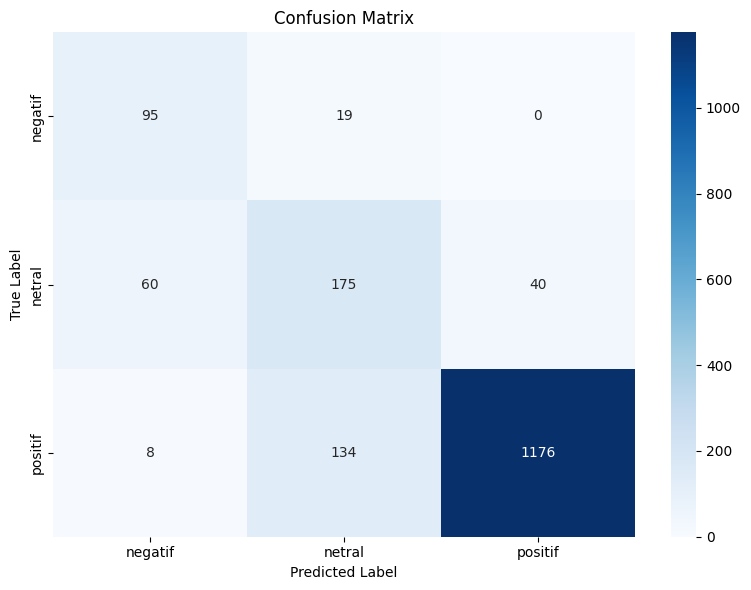

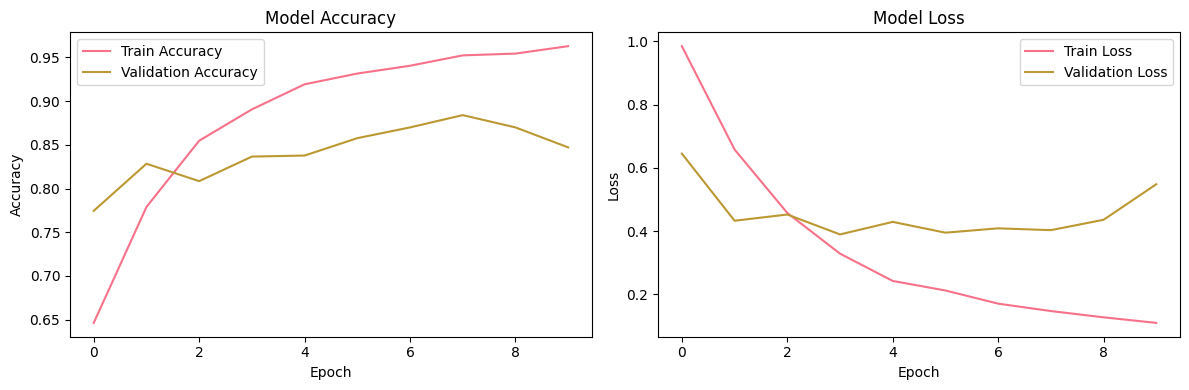

In [10]:

# ===== 8. EVALUASI MODEL =====
print("\n8. EVALUASI MODEL...")

# Predictions
y_pred_proba = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test, axis=1)

# Convert back to labels
y_pred_labels = label_encoder.inverse_transform(y_pred)
y_true_labels = label_encoder.inverse_transform(y_true)

# Metrics
accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Akurasi: {accuracy:.4f}")
print(f"F1-Score (weighted): {f1:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true_labels, y_pred_labels))

# Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()



9. VISUALISASI HASIL...


<Figure size 1400x800 with 0 Axes>

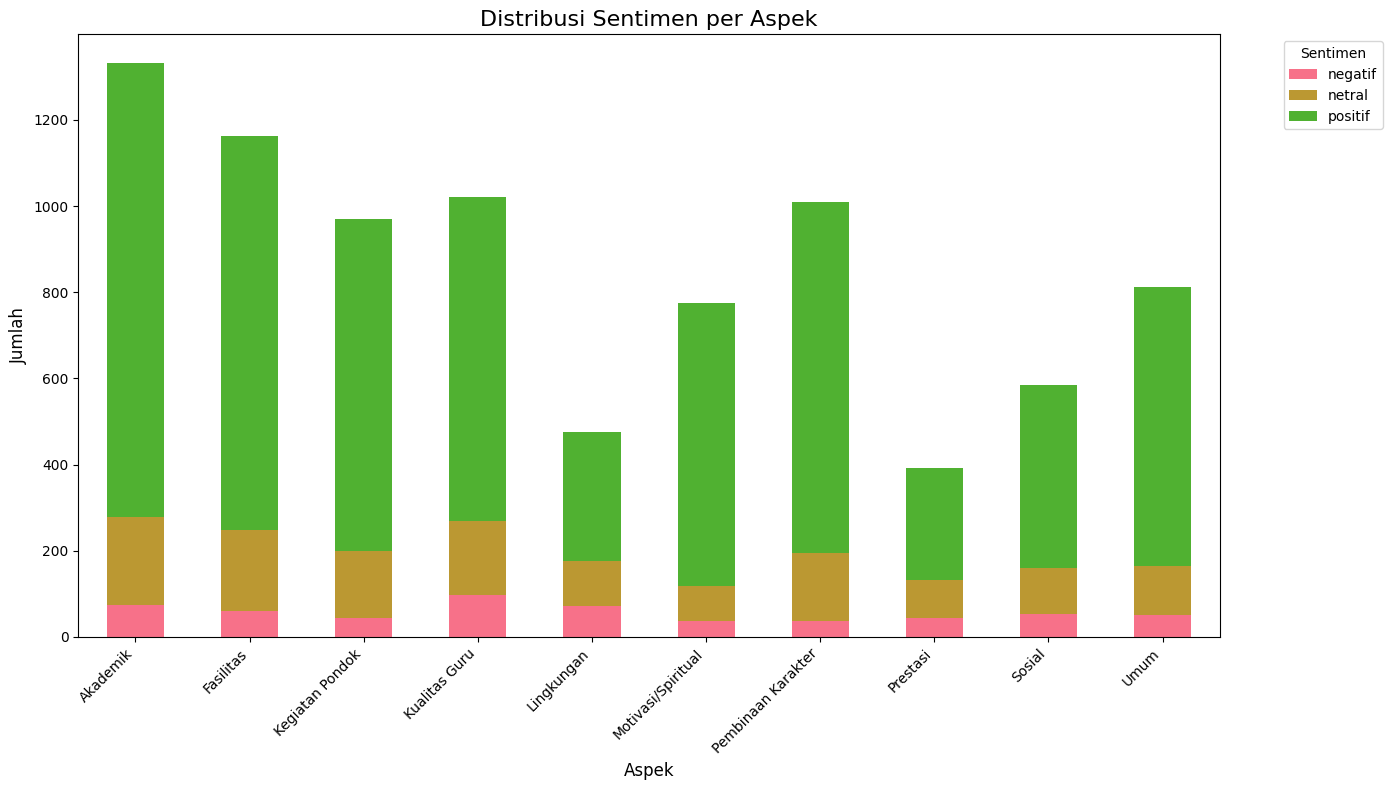

<Figure size 1200x600 with 0 Axes>

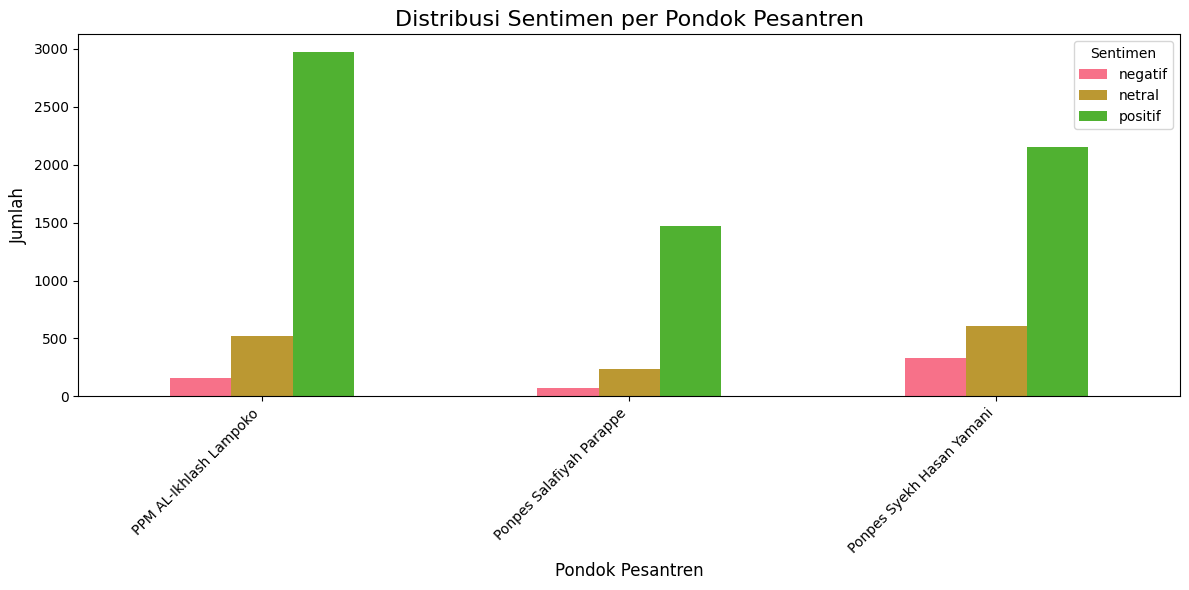

<Figure size 1200x800 with 0 Axes>

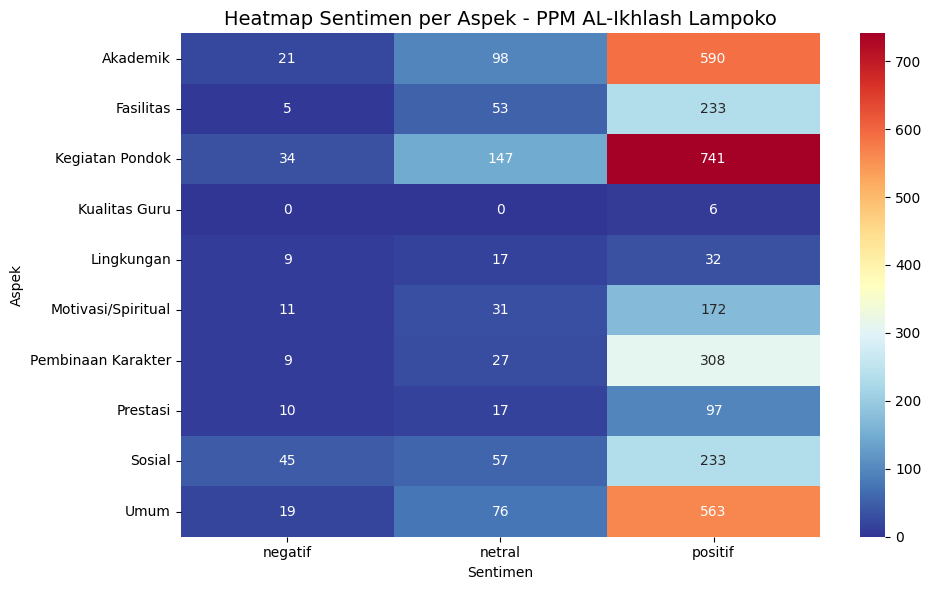

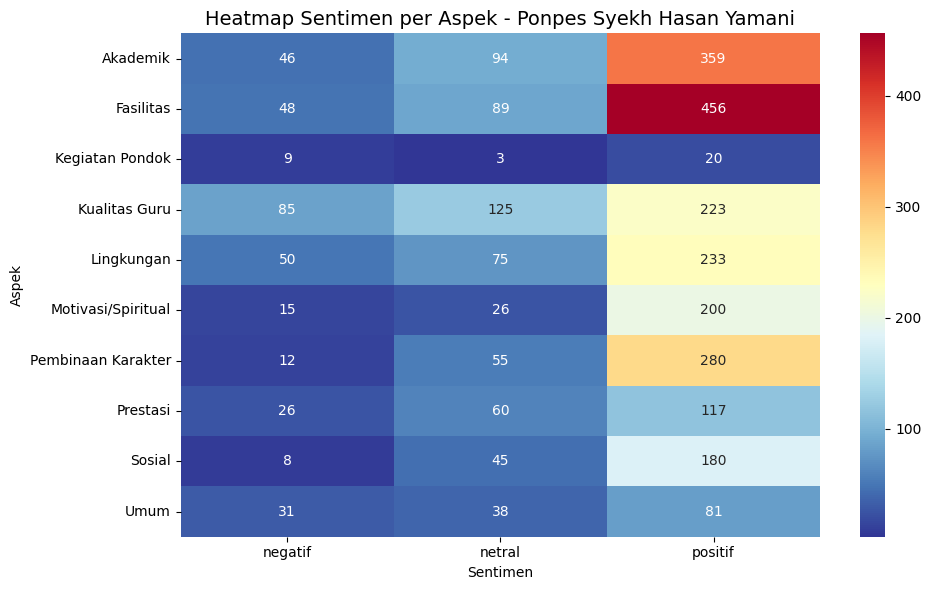

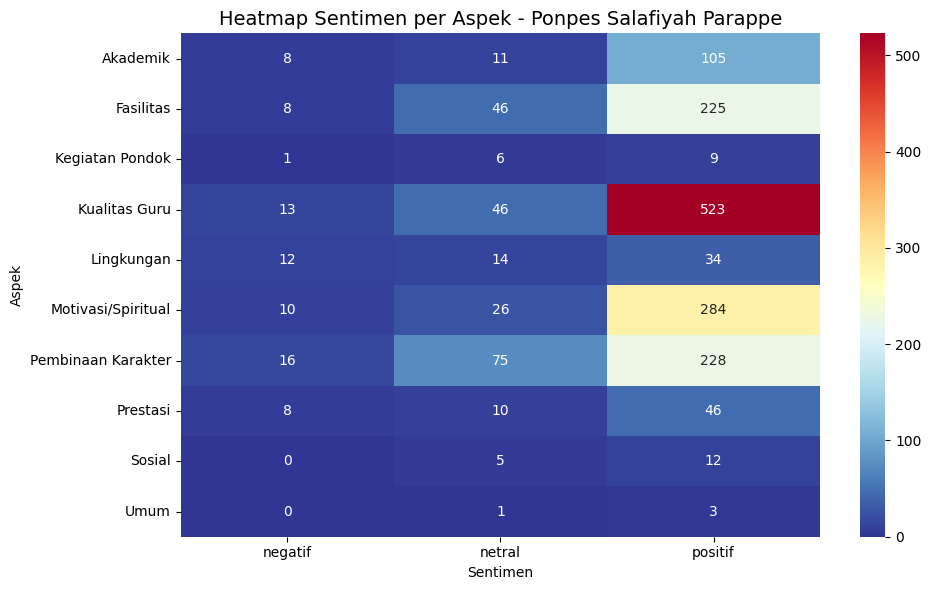

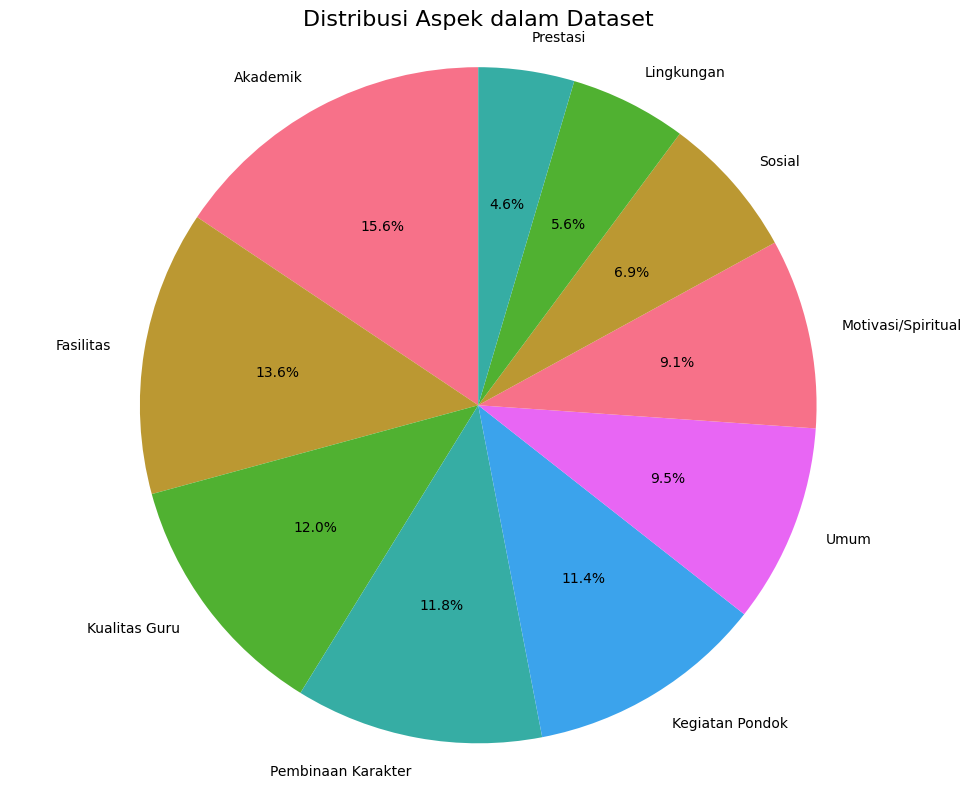


=== RINGKASAN HASIL ===
Total kalimat dianalisis: 8535
Jumlah pondok pesantren: 3
Jumlah aspek: 10
Akurasi model LSTM: 0.8471
F1-Score model LSTM: 0.8560

Distribusi sentimen keseluruhan:
- positif: 77.2%
- netral: 16.1%
- negatif: 6.7%

Aspek paling sering dibahas:
- Akademik: 1332 kalimat
- Fasilitas: 1163 kalimat
- Kualitas Guru: 1021 kalimat
- Pembinaan Karakter: 1010 kalimat
- Kegiatan Pondok: 970 kalimat

Hasil analisis disimpan ke: hasil_absa.xlsx

=== PIPELINE SELESAI ===


In [11]:

# ===== 9. VISUALISASI PER ASPEK DAN PONDOK PESANTREN =====
print("\n9. VISUALISASI HASIL...")

# Distribusi sentimen per aspek
plt.figure(figsize=(14, 8))
sentiment_aspect = pd.crosstab(final_df['aspek'], final_df['label_sentimen'])
sentiment_aspect.plot(kind='bar', stacked=True, figsize=(14, 8))
plt.title('Distribusi Sentimen per Aspek', fontsize=16)
plt.xlabel('Aspek', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentimen', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Distribusi sentimen per pondok pesantren
plt.figure(figsize=(12, 6))
sentiment_ponpes = pd.crosstab(final_df['ponpes'], final_df['label_sentimen'])
sentiment_ponpes.plot(kind='bar', figsize=(12, 6))
plt.title('Distribusi Sentimen per Pondok Pesantren', fontsize=16)
plt.xlabel('Pondok Pesantren', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentimen')
plt.tight_layout()
plt.show()

# Heatmap sentimen per aspek dan pondok
plt.figure(figsize=(12, 8))
aspect_ponpes_sentiment = final_df.groupby(['ponpes', 'aspek', 'label_sentimen']).size().unstack(fill_value=0)
for ponpes in final_df['ponpes'].unique():
    plt.figure(figsize=(10, 6))
    data_ponpes = final_df[final_df['ponpes'] == ponpes]
    sentiment_heatmap = pd.crosstab(data_ponpes['aspek'], data_ponpes['label_sentimen'])
    sns.heatmap(sentiment_heatmap, annot=True, fmt='d', cmap='RdYlBu_r')
    plt.title(f'Heatmap Sentimen per Aspek - {ponpes}', fontsize=14)
    plt.xlabel('Sentimen')
    plt.ylabel('Aspek')
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Pie chart distribusi aspek
plt.figure(figsize=(10, 8))
aspect_counts = final_df['aspek'].value_counts()
plt.pie(aspect_counts.values, labels=aspect_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribusi Aspek dalam Dataset', fontsize=16)
plt.axis('equal')
plt.tight_layout()
plt.show()

# Summary statistics
print("\n=== RINGKASAN HASIL ===")
print(f"Total kalimat dianalisis: {len(final_df)}")
print(f"Jumlah pondok pesantren: {final_df['ponpes'].nunique()}")
print(f"Jumlah aspek: {final_df['aspek'].nunique()}")
print(f"Akurasi model LSTM: {accuracy:.4f}")
print(f"F1-Score model LSTM: {f1:.4f}")

print("\nDistribusi sentimen keseluruhan:")
sentiment_dist = final_df['label_sentimen'].value_counts(normalize=True) * 100
for sentiment, percentage in sentiment_dist.items():
    print(f"- {sentiment}: {percentage:.1f}%")

print("\nAspek paling sering dibahas:")
top_aspects = final_df['aspek'].value_counts().head(5)
for aspect, count in top_aspects.items():
    print(f"- {aspect}: {count} kalimat")

# Save results
final_df.to_excel('/content/hasil_absa.xlsx', index=False)
print(f"\nHasil analisis disimpan ke: hasil_absa.xlsx")

print("\n=== PIPELINE SELESAI ===")